# Visualisering av studenters tentamensresultat med 3D-ytor och spridningsdiagram (PROC G3D)


## Sammanfattning

Denna notebook använder **PROC G3D** för att visualisera hur två
undervisningsinterventionsfaktorer tillsammans formar studentresultat i
en utbildningsanalytisk miljö. Ett komplett faktoriellt rutnät driver en
jämn responsyta av förutsedda tentamensresultat över veckovis studietid
(0 till 20) och tidigare betygsgenomsnitt (GPA, 0 till 4), och en
syntetisk kohort på 100 studenter renderas som **3D-spridnings**paneler
uppdelade efter prestationsnivå.

Den anpassade ytan stiger från ett förutsett resultat nära 26 vid noll
studietimmar mot ett tak nära 99, och planar ut när studietiden passerar
ungefär 10 timmar — den avtagande-avkastning-ås som modellen kodar.
Studentpanelerna bekräftar mönstret på individnivå: de 20 *Utmärkt*-
studenterna (alla med minst 85 poäng) sitter i hörnet med hög GPA och
hög studietid, medan de 33 *Risk*-studenterna koncentreras till
regionen med låg insats och låg GPA. En WHERE-filtrerad vy av det
hörnet isolerar 35 studenter för vilka blygsamma ökningar av studietid
ger de största marginella vinsterna.


## Datakällor

All data genereras inline med `call streaminit()` och `rand()` — inga
externa filer eller nätverksåtkomst.

**`score_grid`** — komplett faktoriellt rutnät som driver responsytan
(en rad per studietid x tidigare-GPA-cell, 99 rader).

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `study_hours` | Num | Veckovis självstudietid, 0 till 20 i steg om 2 (X-axel) |
| `prior_gpa` | Num | Tidigare terminens GPA på en 0–4-skala, 0 till 4 i steg om 0,5 (Y-axel) |
| `pred_score` | Num | Modellerat sluttentamensresultat 0–100 från en mättande responsmodell (Z-axel) |

**`students`** — syntetisk individuell studentkohort för spridningsdiagrammet (100 rader).

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `student_id` | Num | Sekventiell studentidentifierare |
| `study_hours` | Num | Observerad veckovis studietid (X-axel) |
| `prior_gpa` | Num | Observerad tidigare terminens GPA (Y-axel) |
| `exam_score` | Num | Observerat sluttentamensresultat 0–100 (Z-axel) |
| `cohort` | Char | Inskrivningskohort, `Höst` eller `Vår` |
| `band` | Char | Prestationsnivå: `Utmärkt` (≥85), `Godkänd` (65–84), `Risk` (<65) |

Rutnätet är avsiktligt dimensionerat till 99 celler så att det täcker
hela intervallet 0–20 studietimmar och 0–4 GPA samtidigt som det håller
sig inom miljöns gräns på 100 observationer; ett 11 x 9-rutnät håller
ytan jämn utan att trunkera någon axel.


# Visualisering av studenters tentamensresultat med PROC G3D

Utbildningsforskare vill ofta förstå hur två påverkbara faktorer
tillsammans driver ett resultat. Här frågar vi: *hur samverkar
veckovis studietid och en students tidigare GPA för att forma
sluttentamensresultatet?*

Ett tvådimensionellt diagram kan inte visa en interaktionsyta. **PROC
G3D** ritar äkta tredimensionella grafer från variabler i
`y*x=z`-notation, där X och Y spänner över det horisontella planet och
Z stiger vertikalt. Vi använder två av dess funktioner:

- **PLOT** — en kontinuerlig respons-*yta* över ett komplett rutnät av de två prediktorerna.
- **SCATTER** — enskilda studenter plottade som 3D-symboler. Vi ritar en panel per prestationsnivå, var och en med sin egen markörfärg och form, så att de tre resultatnivåerna är lätta att jämföra.

Allt nedan körs på syntetisk data genererad inline, så notebooken är helt självständig.


## Steg 1 — Generera responsytans rutnät

Ett G3D-ytdiagram behöver ett rimligt komplett rutnät: det kräver
icke-saknade Z-värden för minst hälften av X-Y-cellerna. Vi garanterar
ett *komplett* rutnät genom att nästla två `DO`-loopar över
`study_hours` (0 till 20 i steg om 2) och `prior_gpa` (0 till 4 i steg
om 0,5) — ett 11 x 9-rutnät med 99 celler som täcker båda axlarna helt.

Det förutsedda resultatet följer en rimlig mättande modell: avkastningen
på studier avtar vid höga timtal, tidigare GPA bidrar ungefär linjärt,
och de två interagerar (en stark student omvandlar studietid till poäng
mer effektivt). Ett litet reproducerbart brus från `rand('NORMAL')`
hindrar ytan från att se perfekt analytisk ut. `call streaminit()`
fixerar fröet så att rutnätet är reproducerbart.


In [1]:
data score_grid;
   CALL streaminit(20260531);
   GÖR study_hours = 0 TILL 20 EFTER 2;     /* 11 värden: hela intervallet 0-20 */
      GÖR prior_gpa = 0 TILL 4 EFTER 0.5;   /* 9 värden -> 99 rutnätsceller */
         /* avtagande avkastning på studietid */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* tidigare prestation och en interaktionsterm */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         OM pred_score > 100 SÅ pred_score = 100;
         OM pred_score < 0   SÅ pred_score = 0;
         UTDATA;
      SLUT;
   SLUT;
   BEHÅLL study_hours prior_gpa pred_score;
KÖR;

PROCEDUR MEDELVÄRDEN data=score_grid n MIN mean MAX maxdec=1;
   VARIABEL study_hours prior_gpa pred_score;
   ETIKETT study_hours='Veckovis studietid'
         prior_gpa='Tidigare terminens GPA'
         pred_score='Förutsett tentamensresultat';
KÖR;


                                                  The MEANS Procedure

 Variable     Label                               N     Minimum        Mean     Maximum
 --------------------------------------------------------------------------------------
 study_hours  Veckovis studietid                 99         0.0        10.0        20.0
 prior_gpa    Tidigare terminens GPA             99         0.0         2.0         4.0
 pred_score   Förutsett tentamensresultat        99        25.7        70.0        98.7
 --------------------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Steg 2 — Rita den ursprungliga responsytan

Med ett komplett rutnät i handen ritar det enklaste anropet ytan med
procedurens standardinställningar. Syntaxen `PLOT y*x=z` mappar
`prior_gpa` till Y-axeln, `study_hours` till X-axeln och det förutsedda
resultatet till den vertikala Z-axeln.

Vi märker axlarna med ett `LABEL`-uttalande och sätter titlar och en
fotnot med de globala `TITLE`/`FOOTNOTE`-uttalandena så att grafen läses
tydligt.


                                        Yta för förutsett sluttentamensresultat                                         
                                     Effekt av veckovis studietid och tidigare GPA                                      

PROC G3D Output
Data: score_grid

Variables: Veckovis studietid, Tidigare terminens GPA, Förutsett tentamensresultat

Veckovis studietid  Tidigare terminens GPA   Förutsett tentamensresultat
------------------  ----------------------  ----------------------------
                 0                       0                 25.7031536911
                 0                     0.5                 28.9516502743
                 0                       1                 32.3400787822
                 0                     1.5                 36.8265757618
                 0                       2                 40.7806886968
                 0                     2.5                   42.61364606
                 0                       3             


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Yta för förutsett sluttentamensresultat.
NOTE: Option TITLE2 changed to Effekt av veckovis studietid och tidigare GPA.
NOTE: Option FOOTNOTE changed to Syntetisk utbildningsanalytisk data .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


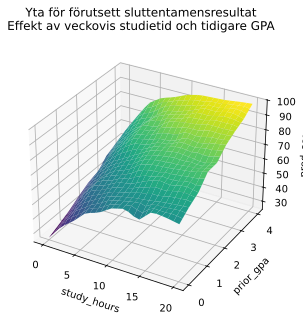

In [2]:
GOPTIONS reset=GLOBAL BORDER;

TITEL 'Yta för förutsett sluttentamensresultat';
title2 'Effekt av veckovis studietid och tidigare GPA';
footnote j=r 'Syntetisk utbildningsanalytisk data ';

PROCEDUR g3d data=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   ETIKETT study_hours = 'Veckovis studietid'
         prior_gpa   = 'Tidigare terminens GPA'
         pred_score  = 'Förutsett tentamensresultat';
KÖR;
QUIT;


## Steg 3 — Förfina ytan med vy- och axelalternativ

Några alternativ gör ytan betydligt mer läsbar:

- **ROTATE=** och **TILT=** ställer in visningsvinkeln (grader runt Z-axeln, och lutning mot betraktaren).
- **XYTYPE=2** ritar ytlinjer parallella med Y-axeln, vilket betonar hur resultatet stiger med studietid.
- **SIDE** lägger till en sidovägg för ett solitt, skulpterat utseende.
- **GRID** lägger till referenslinjer vid de större skalstrecken.
- **ZMIN=/ZMAX=** och **ZTICKNUM=**-familjen fixerar resultataxeln till hela 0–100-intervallet så att ytan inte visuellt överdrivs, medan **XTICKNUM=/YTICKNUM=** styr golvplanets skalstreck.
- **NAME=** och **DESCRIPTION=** märker grafen i utdatakatalogen.


                                  Yta för förutsett tentamensresultat (stiliserad vy)                                   
                                             Roterad, lutad och axelskalad                                              

PROC G3D Output
Data: score_grid

Variables: Veckovis studietid, Tidigare terminens GPA, Förutsett tentamensresultat

Veckovis studietid  Tidigare terminens GPA   Förutsett tentamensresultat
------------------  ----------------------  ----------------------------
                 0                       0                 25.7031536911
                 0                     0.5                 28.9516502743
                 0                       1                 32.3400787822
                 0                     1.5                 36.8265757618
                 0                       2                 40.7806886968
                 0                     2.5                   42.61364606
                 0                       3             


NOTE: Option TITLE changed to Yta för förutsett tentamensresultat (stiliserad vy).
NOTE: Option TITLE2 changed to Roterad, lutad och axelskalad.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


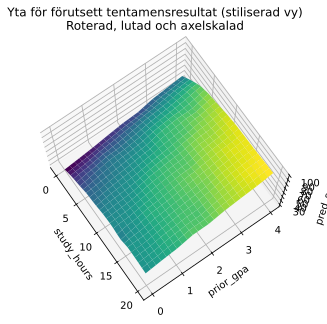

In [3]:
TITEL 'Yta för förutsett tentamensresultat (stiliserad vy)';
title2 'Roterad, lutad och axelskalad';

PROCEDUR g3d data=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Stiliserad responsyta för tentamensresultat";
   ETIKETT study_hours = 'Veckovis studietid'
         prior_gpa   = 'Tidigare terminens GPA'
         pred_score  = 'Förutsett tentamensresultat';
KÖR;
QUIT;


## Steg 4 — Jämför ytan från flera visningsvinklar

Eftersom en 3D-yta kan dölja struktur bakom sina egna toppar hjälper det
att rendera samma yta från mer än en rotation. Här utfärdar vi tre PROC
G3D-steg som delar en fast lutning men stegar **ROTATE=**-vinkeln genom
30, 90 och 150 grader, så att åsen kan inspekteras framifrån, från sidan
och bakifrån.


                                                       Responsyta                                                       
                                              ROTATE = 30 vid fast lutning                                              

PROC G3D Output
Data: score_grid

Variables: Veckovis studietid, Tidigare terminens GPA, Förutsett tentamensresultat

Veckovis studietid  Tidigare terminens GPA   Förutsett tentamensresultat
------------------  ----------------------  ----------------------------
                 0                       0                 25.7031536911
                 0                     0.5                 28.9516502743
                 0                       1                 32.3400787822
                 0                     1.5                 36.8265757618
                 0                       2                 40.7806886968
                 0                     2.5                   42.61364606
                 0                       3             


NOTE: Option TITLE changed to Responsyta.
NOTE: Option TITLE2 changed to ROTATE = 30 vid fast lutning.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Responsyta.
NOTE: Option TITLE2 changed to ROTATE = 90 vid fast lutning.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Responsyta.
NOTE: Option TITLE2 changed to ROTATE = 150 vid fast lutning.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


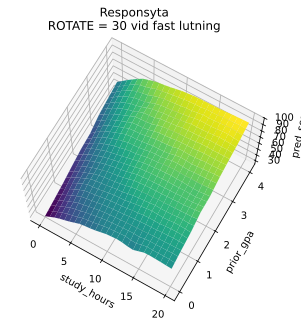

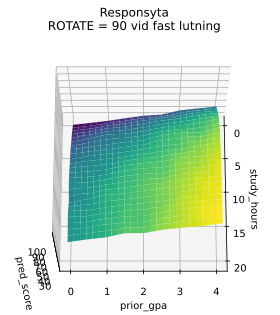

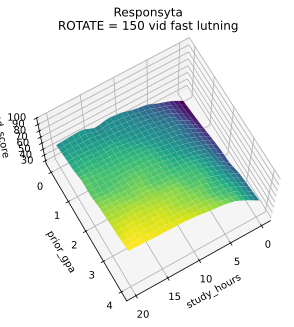

In [4]:
%macro angle(deg);
   TITEL 'Responsyta';
   title2 "ROTATE = &deg vid fast lutning";
   PROCEDUR g3d data=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      ETIKETT study_hours = 'Veckovis studietid'
            prior_gpa   = 'Tidigare terminens GPA'
            pred_score  = 'Förutsett tentamensresultat';
   KÖR;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);


## Steg 5 — Generera en syntetisk studentkohort

Ytan är en modell; verkliga studenter sprids kring den. Vi simulerar nu
100 enskilda studenter hämtade från två inskrivningskohorter (`Höst`,
`Vår`). Varje student har observerad studietid, en tidigare GPA och ett
brusigt realiserat tentamensresultat genererat från samma responslogik
plus större individuell variation.

Vi härleder sedan en prestations-**nivå** från tentamensresultatet:
`Utmärkt` (85 eller mer), `Godkänd` (65 till 84) och `Risk` (under 65).
PROC FREQ-korstabuleringen nedan rapporterar hur nivåerna fördelas över
de två kohorterna. `rand('UNIFORM')` och `rand('NORMAL')` ger
slumpmässigheten; fröet håller den reproducerbar.


                                                       Responsyta                                                       
                                             ROTATE = 150 vid fast lutning                                              

                                                   The FREQ Procedure

                                 Cumulative
Prestationsnivå     Frequency    Frequency
----------------------------------------------
Godkänd                    47           47
Risk                       33           80
Utmärkt                    20          100

Table of Kohort by Prestationsnivå

Kohort |   Godkänd |      Risk |   Utmärkt |      Total
-------+-----------+-----------+-----------+-----------
Höst   |        20 |        15 |         6 |         41
-------+-----------+-----------+-----------+-----------
Vår    |        27 |        18 |        14 |         59
-------+-----------+-----------+-----------+-----------
Total  |        47 |        33 |        20 |      


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


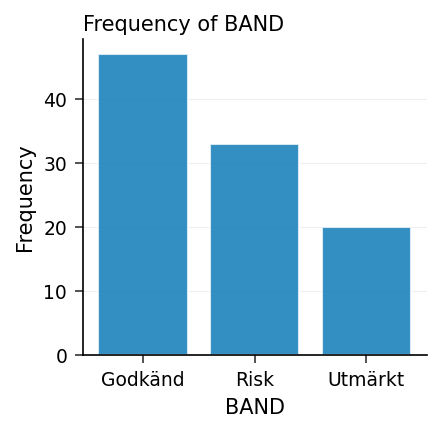

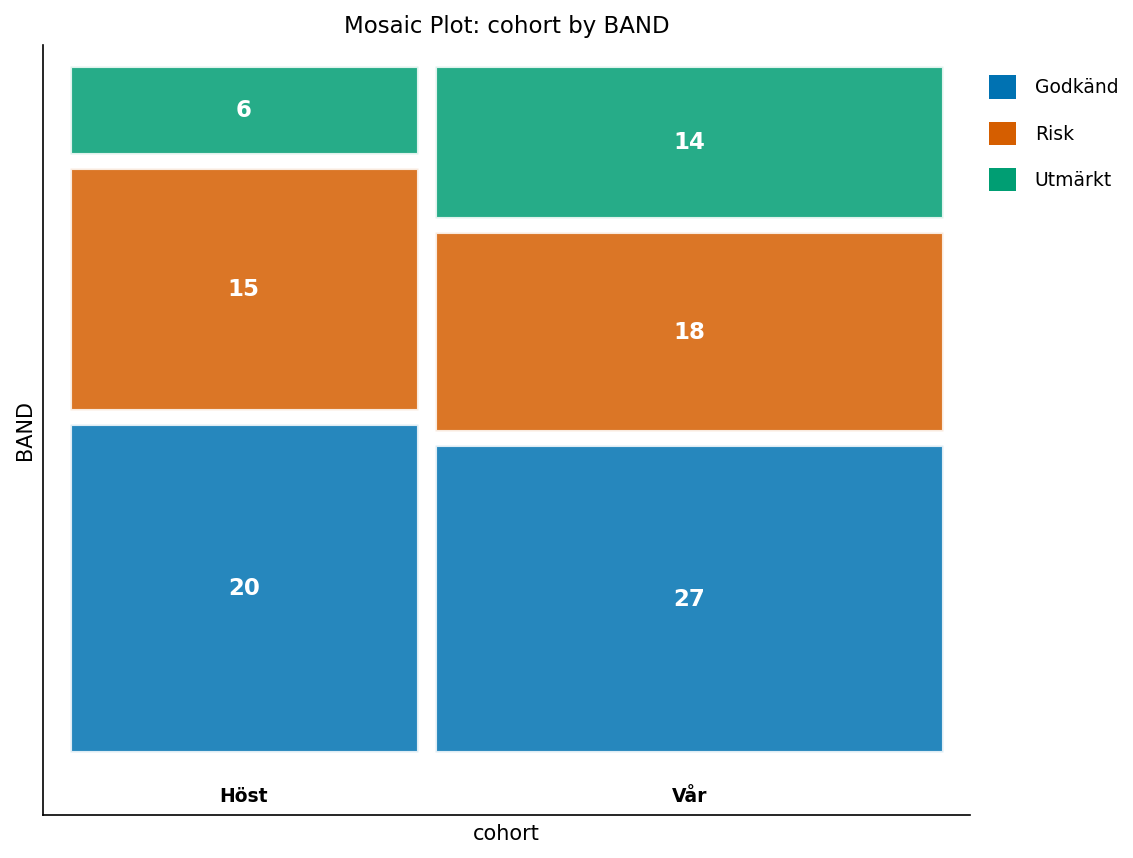

In [5]:
data students;
   CALL streaminit(99001);
   LÄNGD cohort $8 BAND $10;
   GÖR student_id = 1 TILL 100;
      OM rand('UNIFORM') < 0.5 SÅ cohort = 'Höst';
      ANNARS cohort = 'Vår';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      OM exam_score > 100 SÅ exam_score = 100;
      OM exam_score < 0   SÅ exam_score = 0;

      OM exam_score >= 85 SÅ BAND = 'Utmärkt';
      ANNARS OM exam_score >= 65 SÅ BAND = 'Godkänd';
      ANNARS BAND = 'Risk';

      UTDATA;
   SLUT;
   BEHÅLL student_id cohort study_hours prior_gpa exam_score BAND;
KÖR;

PROCEDUR FREKVENSER data=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   ETIKETT cohort = 'Kohort'
         BAND = 'Prestationsnivå';
KÖR;


## Steg 6 — Rita studenter som 3D-spridningspaneler efter prestationsnivå

**SCATTER**-uttalandet placerar varje student som en 3D-symbol. För att
göra de tre resultatnivåerna lätta att läsa ritar vi en panel per nivå,
var och en filtrerad med **WHERE** och given sin egen bokstavliga
**COLOR=** och **SHAPE=**: gröna diamanter (`SHAPE=diamond`) för
*Utmärkt*, blå markörer (`SHAPE=club`) för *Godkänd* och röda markörer
(`SHAPE=spade`) för *Risk*. **SIZE=** förstorar markörerna, **GRID**
lägger till golvreferenslinjer, **NONEEDLE** tar bort de vertikala
fallinjerna, och **ZMIN=/ZMAX=** håller varje panel till samma
0–100-resultataxel så att de tre vyerna är direkt jämförbara.

Varje nivå får sitt eget PROC G3D-steg så att dess WHERE-filter
appliceras rent och markörstilen är entydig.


                                                 Studenter med Utmärkt                                                  
                                            Tentamensresultat 85 och däröver                                            

PROC G3D Output
Data: students

Variables: student_id, cohort, Veckovis studietid, Tidigare terminens GPA, Tentamensresultat, BAND

student_id      cohort  Veckovis studietid  Tidigare terminens GPA  Tentamensresultat        BAND
----------  ----------  ------------------  ----------------------  -----------------  ----------
         2         Vår       19.2134883194            2.6467742616      90.3663886999     Utmärkt
         5         Vår       15.5520919174            2.7102003827      94.9419468332     Utmärkt
        10         Vår       14.2302640951            3.8791496428                100     Utmärkt
        17         Vår       13.7403346635            2.7462821708      89.6648779222     Utmärkt
        25        Höst       18.75921


NOTE: Option FOOTNOTE changed to Från en kohort på 100 syntetiska studenter .
NOTE: Option TITLE changed to Studenter med Utmärkt.
NOTE: Option TITLE2 changed to Tentamensresultat 85 och däröver.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Studenter med Godkänd.
NOTE: Option TITLE2 changed to Tentamensresultat 65 till 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Studenter i Risk.
NOTE: Option TITLE2 changed to Tentamensresultat under 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


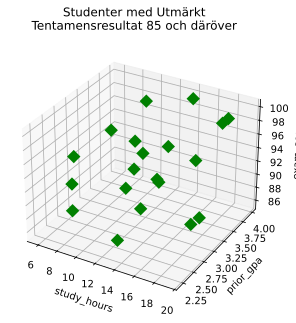

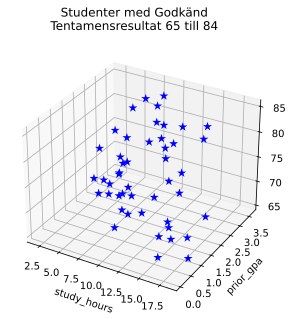

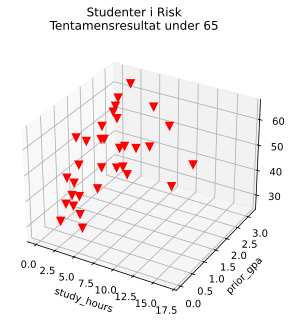

In [6]:
footnote j=r 'Från en kohort på 100 syntetiska studenter ';

/* Utmärkt (exam_score >= 85): gröna diamanter */
TITEL 'Studenter med Utmärkt';
title2 'Tentamensresultat 85 och däröver';
PROCEDUR g3d data=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Studenter med Utmärkt";
   DÄR BAND = 'Utmärkt';
   ETIKETT study_hours = 'Veckovis studietid'
         prior_gpa   = 'Tidigare terminens GPA'
         exam_score  = 'Tentamensresultat';
KÖR;
QUIT;

/* Godkänd (65 <= exam_score < 85): blå klöver */
TITEL 'Studenter med Godkänd';
title2 'Tentamensresultat 65 till 84';
PROCEDUR g3d data=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Studenter med Godkänd";
   DÄR BAND = 'Godkänd';
   ETIKETT study_hours = 'Veckovis studietid'
         prior_gpa   = 'Tidigare terminens GPA'
         exam_score  = 'Tentamensresultat';
KÖR;
QUIT;

/* Risk (exam_score < 65): röda spader */
TITEL 'Studenter i Risk';
title2 'Tentamensresultat under 65';
PROCEDUR g3d data=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Studenter i Risk";
   DÄR BAND = 'Risk';
   ETIKETT study_hours = 'Veckovis studietid'
         prior_gpa   = 'Tidigare terminens GPA'
         exam_score  = 'Tentamensresultat';
KÖR;
QUIT;


## Steg 7 — Separata spridningsdiagram per inskrivningskohort (BY-grupp)

Programledare behöver ofta samma vy uppdelad efter kohort.
**BY**-uttalandet producerar ett spridningsdiagram per kohort. G3D
förväntar sig att BY-gruppdata är sorterad, så vi sorterar först med
PROC SORT. Varje kohort får sedan sitt eget märkta 3D-spridningsdiagram
på en delad 0–100-resultataxel, vilket gör Höst- och
Vår-fördelningarna lätta att jämföra sida vid sida.


                                        Tentamensutfall efter inskrivningskohort                                        
                                    Ett 3D-spridningsdiagram per kohort (Höst, Vår)                                     

PROC G3D Output
Data: students_sorted

Variables: student_id, cohort, Veckovis studietid, Tidigare terminens GPA, Tentamensresultat, BAND

student_id      cohort  Veckovis studietid  Tidigare terminens GPA  Tentamensresultat        BAND
----------  ----------  ------------------  ----------------------  -----------------  ----------
        52        Höst       15.2586640362            0.4602308374      55.5186804916        Risk
        13        Höst        5.8493366471            1.8449001873      70.6084324429     Godkänd
        15        Höst        5.5070892672            1.4478111608      70.0069314398     Godkänd
        22        Höst        0.0365105382            1.3187236247      35.9197853017        Risk
        24        Höst       1


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Tentamensutfall efter inskrivningskohort.
NOTE: Option TITLE2 changed to Ett 3D-spridningsdiagram per kohort (Höst, Vår).
NOTE: Option FOOTNOTE changed to En panel per kohort .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


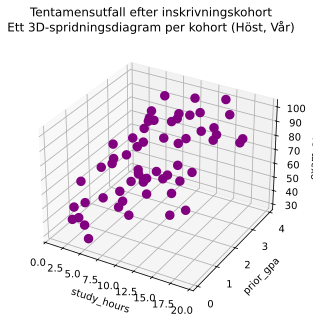

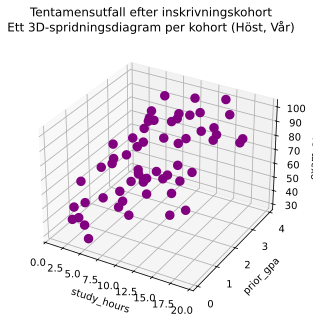

In [7]:
PROCEDUR SORTERA data=students out=students_sorted;
   EFTER cohort;
KÖR;

TITEL 'Tentamensutfall efter inskrivningskohort';
title2 'Ett 3D-spridningsdiagram per kohort (Höst, Vår)';
footnote j=r 'En panel per kohort ';

PROCEDUR g3d data=students_sorted;
   EFTER cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   ETIKETT study_hours = 'Veckovis studietid'
         prior_gpa   = 'Tidigare terminens GPA'
         exam_score  = 'Tentamensresultat';
KÖR;
QUIT;


## Steg 8 — Fokusera på riskregionen med WHERE

För interventionsplanering är den mest handlingsbara vyn den nedre
vänstra delen av ytan: studenter med både blygsam studietid (8 timmar
eller mindre) och lägre tidigare GPA (2,5 eller lägre). **WHERE**-
uttalandet begränsar spridningsdiagrammet till den regionen innan
plottning. Listan visar att detta hörn rymmer 35 av de 100 studenterna
— 22 av dem redan *Risk* — så att rådgivare kan se exakt vilka
kämpande studenter som ligger längst under förväntan.


                              Interventionsfokus: studenter med lägre insats och lägre GPA                              
                                         study_hours <= 8 and prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: student_id, cohort, Veckovis studietid, Tidigare terminens GPA, Tentamensresultat, BAND

student_id      cohort  Veckovis studietid  Tidigare terminens GPA  Tentamensresultat        BAND
----------  ----------  ------------------  ----------------------  -----------------  ----------
         1        Höst        4.9780700766             1.072086769       59.409228777        Risk
         7         Vår        7.9015823058            1.6623636789      66.9055021729     Godkänd
         9         Vår        2.5008494545            0.3621033759      48.1183184446        Risk
        11         Vår        7.1907276895            2.1821388818       79.351887155     Godkänd
        13        Höst        5.84933


NOTE: Option TITLE changed to Interventionsfokus: studenter med lägre insats och lägre GPA.
NOTE: Option TITLE2 changed to study_hours <= 8 and prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Nålar drar varje markör till golvet för studietid x GPA .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


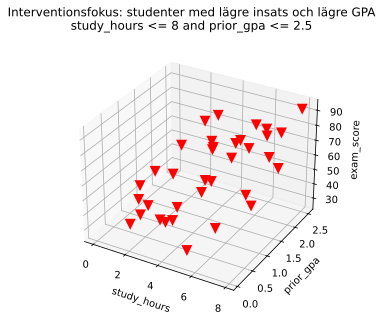

In [8]:
TITEL 'Interventionsfokus: studenter med lägre insats och lägre GPA';
title2 'study_hours <= 8 and prior_gpa <= 2.5';
footnote j=r 'Nålar drar varje markör till golvet för studietid x GPA ';

PROCEDUR g3d data=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   DÄR study_hours <= 8 AND prior_gpa <= 2.5;
   ETIKETT study_hours = 'Veckovis studietid'
         prior_gpa   = 'Tidigare terminens GPA'
         exam_score  = 'Tentamensresultat';
KÖR;
QUIT;


## Tolkning av resultaten

**Responsytan** (steg 2–4) visar en tydlig avtagande-avkastning-ås.
Över det 99-celliga rutnätet går det förutsedda resultatet från cirka
26 (noll studietimmar, noll GPA) upp till cirka 99 (hörnet med hög
studietid och hög GPA), med ett rutnätsomfattande medelvärde nära 70.
Läser man längs studietidsaxeln stiger resultaten brant från 0 mot
ungefär 10 timmar och planar sedan ut när ytterligare timmar ger
avtagande avkastning; läser man längs GPA-axeln flyttar tidigare
prestation hela ytan uppåt. Interaktionstermen gör studietidens
avkastning en aning brantare för starkare studenter, vilket är varför
ytan lutar mot sitt bortre hörn snarare än att stiga som ett plant plan.

**Studentpanelerna** (steg 6–7) bekräftar att modellen håller på
individnivå. Kohorten på 100 delas upp i 20 *Utmärkt*-, 47 *Godkänd*-
och 33 *Risk*-studenter. I nivåpanelerna sitter de 20 gröna
*Utmärkt*-diamanterna — var och en med minst 85 poäng — vid tidigare
GPA 2,2 eller högre och minst cirka 6 veckovisa studietimmar,
koncentrerade till golvplanets övre högra hörn. De 33 röda
*Risk*-markörerna koncentreras till regionen med låg insats och låg
GPA, precis i ytans dal. Uppdelning efter kohort visar att
Höst-fördelningen (41 studenter) och Vår-fördelningen (59 studenter)
är i stort sett likartade, vilket antyder att resultaten drivs av de
två faktorerna snarare än inskrivningstidpunkten.

**Den WHERE-filtrerade vyn** (steg 8) isolerar interventionspopulationen:
de 35 studenterna med 8 eller färre studietimmar och en GPA på 2,5 eller
lägre. Tjugotvå är redan *Risk* och endast en når *Utmärkt*. Inom detta
hörn stiger de realiserade resultaten fortfarande synligt med
studietiden — ett konkret, visuellt argument för att blygsamma ökningar
i strukturerad studietid ger de största marginella vinsterna precis där
de behövs mest.

Sammantaget förvandlar PROC G3D en tvåfaktors interaktionsmodell till en
intuitiv, beslutsklar bild för ett utbildningsprogram: var
resultattaket ligger, vem som inte når det och var handledningsinsatser
lönar sig mest.

> **Implementeringsanmärkning.** SAS/GRAPH tillåter också ett enda
> SCATTER-uttalande att färga och forma varje markör från
> observationsspecifika variabler (`COLOR=<teckenvariabel>`,
> `SHAPE=<teckenvariabel>`). Den observationsspecifika formen renderas
> ännu inte i den här motorn, så den här notebooken ritar en
> bokstavligt färgad panel per nivå istället — en likvärdig, fullt
> fungerande presentation. Luckan spåras av det bankade
> regressionstestet `tests/401000_nb_g3d_scatter_color_variable_unrendered`.
